<a href="https://colab.research.google.com/github/Mansehaj-Singh/Drone-Orientation-Estimation/blob/main/Ext_IONET_Fast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()


Saving AP1.xlsx to AP1.xlsx
Saving AP2.xlsx to AP2.xlsx
Saving Qs_fast.xlsx to Qs_fast.xlsx
Saving SH1.xlsx to SH1.xlsx
Saving SH2.xlsx to SH2.xlsx
Saving XS1.xlsx to XS1.xlsx
Saving XS2.xlsx to XS2.xlsx


In [3]:
!pip -q install openpyxl scikit-learn pandas matplotlib

Using device: cpu
Processing: XS1.xlsx
Processing: XS2.xlsx

Total sequences: 1880
Static sequences: 1294
Dynamic sequences: 586

Split sizes:
  Train: 1352
  Val  : 151
  Test : 377

Feature shapes after scaling:
lin_acc (1352, 200, 3)
gyro (1352, 200, 3)
mag (1352, 200, 3)
grav (1352, 200, 3)
inclination (1352, 200, 2)

Training model: 6axis
[6axis] Epoch 01/20 | train_loss=0.576631 | val_loss=0.299334 | best_val=0.299334
[6axis] Epoch 02/20 | train_loss=0.319448 | val_loss=0.224718 | best_val=0.224718
[6axis] Epoch 03/20 | train_loss=0.272874 | val_loss=0.166592 | best_val=0.166592
[6axis] Epoch 04/20 | train_loss=0.238518 | val_loss=0.144481 | best_val=0.144481
[6axis] Epoch 05/20 | train_loss=0.206778 | val_loss=0.119453 | best_val=0.119453
[6axis] Epoch 06/20 | train_loss=0.180829 | val_loss=0.115862 | best_val=0.115862
[6axis] Epoch 07/20 | train_loss=0.159166 | val_loss=0.112688 | best_val=0.112688
[6axis] Epoch 08/20 | train_loss=0.190524 | val_loss=0.303294 | best_val=0.11268

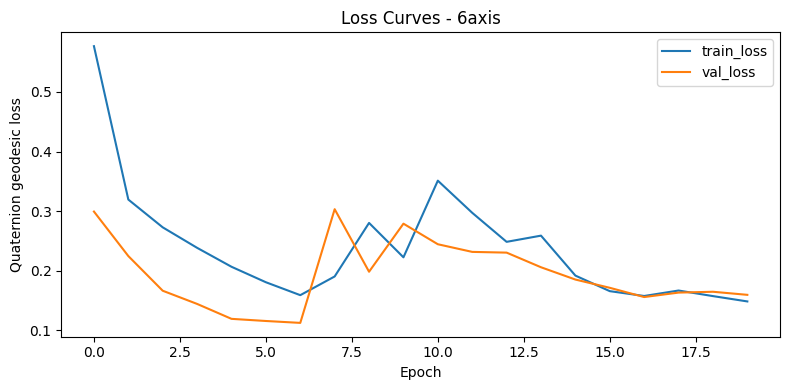

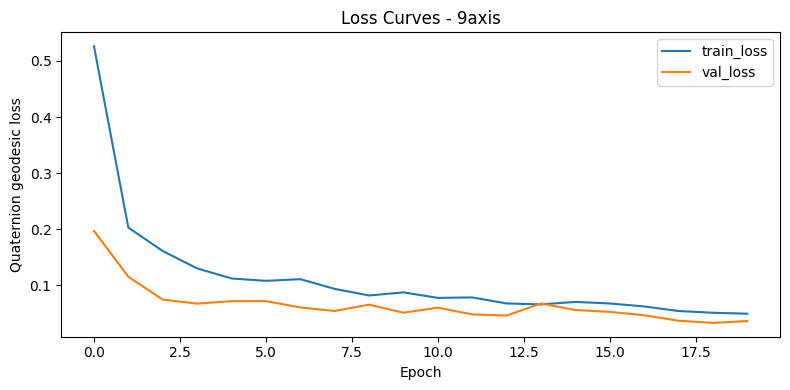

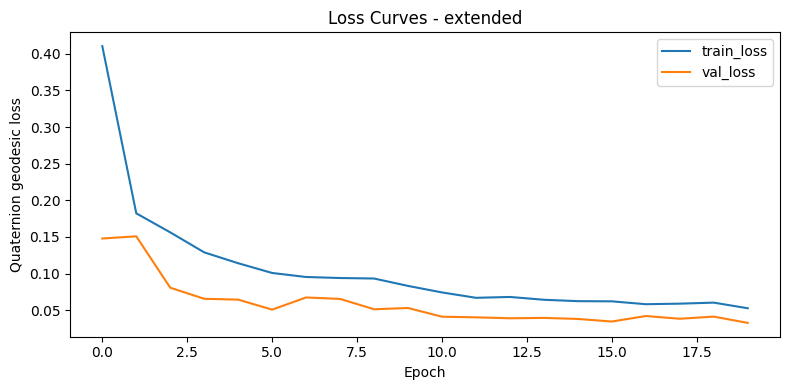

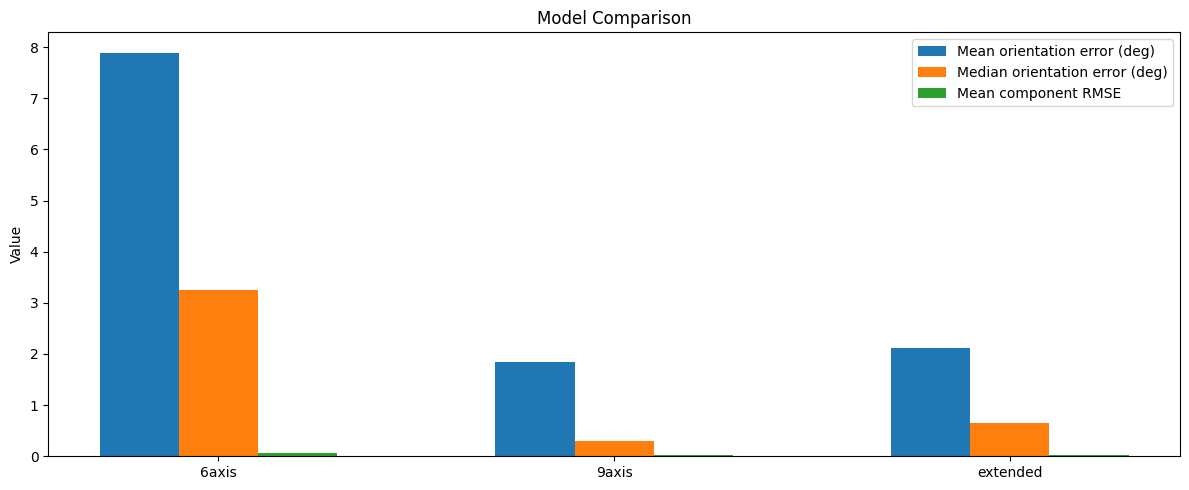

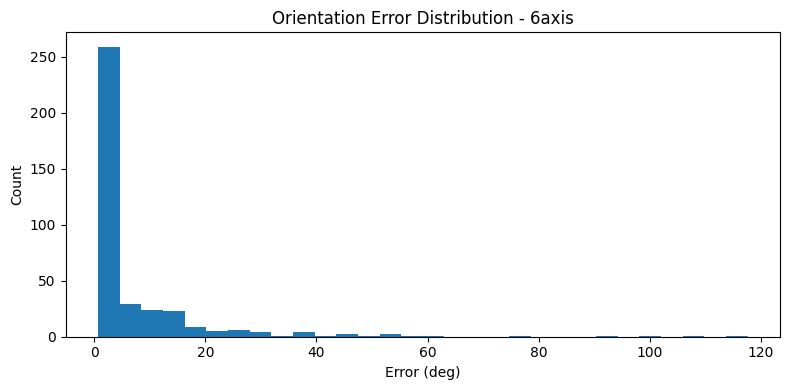

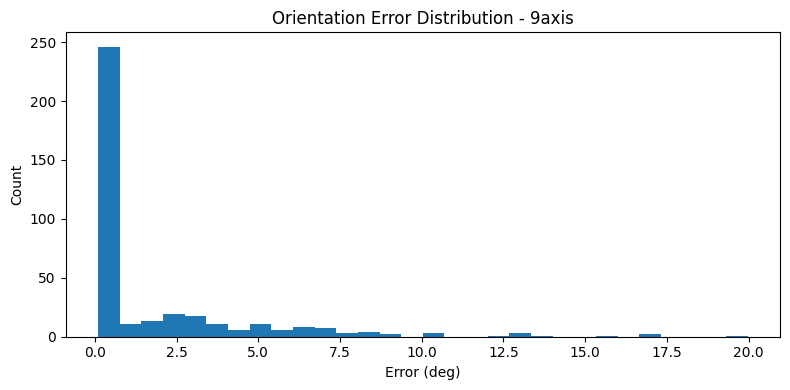

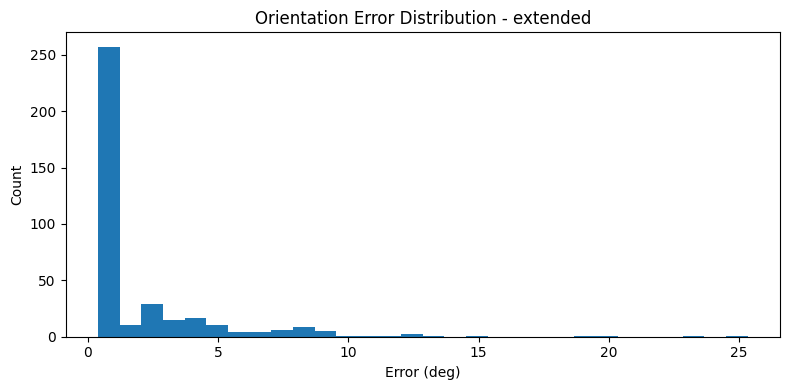


Saved outputs to: /content/ionet_outputs
  - best model checkpoints
  - per-sample predictions CSVs
  - per-threshold AP proxy CSVs
  - metrics JSON/CSV
  - plots


3 SAMPLE PREDICTIONS : EXTENDED

Sample: 0
Ground Truth : [0.7719, 0.0137, 0.6285, -0.0942]
Predicted    : [0.8159, -0.007, 0.5678, -0.1092]
Orientation Error (deg): 9.083

Sample: 188
Ground Truth : [0.0254, -0.0119, -0.0056, -0.9996]
Predicted    : [0.0307, -0.0115, -0.0059, -0.9994]
Orientation Error (deg): 0.605

Sample: 376
Ground Truth : [-0.0051, -0.012, -0.0041, -0.9999]
Predicted    : [-0.0005, -0.012, -0.0054, -0.9999]
Orientation Error (deg): 0.557


In [5]:

import os
import math
import json
import random
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

SEED = 42
SENSOR_FILES = ["XS1.xlsx", "XS2.xlsx", "AP1.xlsx", "AP2.xlsx", "SH1.xlsx", "SH2.xlsx"]
QUAT_FILE = "Qs_fast.xlsx"

SEQ_LEN = 200
STRIDE = 10
MOTION_THRESHOLD = 0.1

BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-5
TEST_SIZE = 0.20
VAL_SIZE = 0.10

RUN_ALL_MODELS = True
MODEL_NAMES = ["6axis", "9axis", "extended"] if RUN_ALL_MODELS else ["extended"]

OUTPUT_DIR = "/content/ionet_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ============================================================
# HELPERS
# ============================================================

def normalize_quaternion_np(q: np.ndarray) -> np.ndarray:
    q = q.astype(np.float32)
    n = np.linalg.norm(q, axis=1, keepdims=True)
    n = np.where(n == 0, 1.0, n)
    return q / n

def normalize_quaternion_torch(q: torch.Tensor) -> torch.Tensor:
    return F.normalize(q, p=2, dim=1)

def align_quaternion_sign(pred: np.ndarray, gt: np.ndarray) -> np.ndarray:
    """Align pred quaternion hemisphere with gt so q and -q are treated consistently."""
    dot = np.sum(pred * gt, axis=1, keepdims=True)
    pred = np.where(dot < 0, -pred, pred)
    return pred

def lowpass_gravity_from_acc(acc: np.ndarray, alpha: float = 0.90) -> np.ndarray:
    """
    Simple EMA low-pass filter to estimate gravity from acceleration.
    """
    g = np.zeros_like(acc, dtype=np.float32)
    if len(acc) == 0:
        return g
    g[0] = acc[0]
    for t in range(1, len(acc)):
        g[t] = alpha * g[t - 1] + (1.0 - alpha) * acc[t]
    return g

def gravity_to_inclination(gravity: np.ndarray) -> np.ndarray:
    """
    Convert gravity vector to roll/pitch-like inclination features (2 channels).
    Returns shape: [T, 2]
    """
    gx = gravity[:, 0]
    gy = gravity[:, 1]
    gz = gravity[:, 2]
    eps = 1e-8
    roll = np.arctan2(gy, np.sqrt(gx * gx + gz * gz) + eps)
    pitch = np.arctan2(gx, np.sqrt(gy * gy + gz * gz) + eps)
    return np.stack([roll, pitch], axis=1).astype(np.float32)

def get_existing_columns(df: pd.DataFrame) -> Dict[str, str]:
    return {str(c).strip().lower(): c for c in df.columns}

def extract_triplet(
    df: pd.DataFrame,
    candidates: List[Tuple[str, str, str]],
    fallback_slice: Tuple[int, int] = None,
    fill_zeros: bool = False
) -> np.ndarray:
    """
    Try a list of candidate triplet column names, otherwise fallback to a slice, otherwise zeros.
    """
    cols = get_existing_columns(df)
    for triplet in candidates:
        if all(name in cols for name in triplet):
            return df[[cols[triplet[0]], cols[triplet[1]], cols[triplet[2]]]].to_numpy(np.float32)
    if fallback_slice is not None and df.shape[1] >= fallback_slice[1]:
        return df.iloc[:, fallback_slice[0]:fallback_slice[1]].to_numpy(np.float32)
    if fill_zeros:
        return np.zeros((len(df), 3), dtype=np.float32)
    raise ValueError("Required triplet columns not found and no fallback available.")

def read_sensor_excel(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df

def read_quaternion_excel(path: str) -> np.ndarray:
    qdf = pd.read_excel(path)
    qdf.columns = [str(c).strip().lower() for c in qdf.columns]
    if {"qw", "qx", "qy", "qz"}.issubset(set(qdf.columns)):
        q = qdf[["qw", "qx", "qy", "qz"]].to_numpy(np.float32)
    else:
        if qdf.shape[1] < 4:
            raise ValueError("Quaternion file must have at least 4 columns.")
        q = qdf.iloc[:, :4].to_numpy(np.float32)
    return normalize_quaternion_np(q)

def compute_motion_label(gyro: np.ndarray, threshold: float = MOTION_THRESHOLD) -> np.ndarray:
    gnorm = np.linalg.norm(gyro, axis=1)
    return (gnorm > threshold).astype(np.int64)

def create_windows_for_file(
    df: pd.DataFrame,
    quat_slice: np.ndarray,
    seq_len: int = SEQ_LEN,
    stride: int = STRIDE,
) -> Tuple[Dict[str, np.ndarray], np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
      X_dict with keys: lin_acc, gyro, mag, grav, inclination
      y: quaternion targets [N,4]
      motion: static(0)/dynamic(1) labels per window
      starts: start index for each window
    """
    cols = get_existing_columns(df)

    # 6-axis core inputs
    acc = extract_triplet(
        df,
        candidates=[("ax", "ay", "az"), ("acc_x", "acc_y", "acc_z"), ("linear_acc_x", "linear_acc_y", "linear_acc_z")],
        fallback_slice=(1, 4),
        fill_zeros=False,
    )
    gyro = extract_triplet(
        df,
        candidates=[("gx", "gy", "gz"), ("gyro_x", "gyro_y", "gyro_z"), ("w_x", "w_y", "w_z")],
        fallback_slice=(4, 7),
        fill_zeros=False,
    )

    # Magnetometer if available, else zeros
    mag = extract_triplet(
        df,
        candidates=[("mx", "my", "mz"), ("mag_x", "mag_y", "mag_z")],
        fallback_slice=(7, 10),
        fill_zeros=True,
    )

    # Gravity if available, else estimate from acceleration using low-pass filter
    grav = None
    grav_candidates = [
        ("grav_x", "grav_y", "grav_z"),
        ("gravity_x", "gravity_y", "gravity_z"),
    ]
    for tri in grav_candidates:
        if all(name in cols for name in tri):
            grav = df[[cols[tri[0]], cols[tri[1]], cols[tri[2]]]].to_numpy(np.float32)
            break
    if grav is None:
        grav = lowpass_gravity_from_acc(acc)

    inclination = gravity_to_inclination(grav)

    n = min(len(df), len(quat_slice))
    acc = acc[:n]
    gyro = gyro[:n]
    mag = mag[:n]
    grav = grav[:n]
    inclination = inclination[:n]
    quat_slice = quat_slice[:n]

    motion = compute_motion_label(gyro)

    if n < seq_len:
        empty = {
            "lin_acc": np.zeros((0, seq_len, 3), dtype=np.float32),
            "gyro": np.zeros((0, seq_len, 3), dtype=np.float32),
            "mag": np.zeros((0, seq_len, 3), dtype=np.float32),
            "grav": np.zeros((0, seq_len, 3), dtype=np.float32),
            "inclination": np.zeros((0, seq_len, 2), dtype=np.float32),
        }
        return empty, np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64), np.zeros((0,), dtype=np.int64)

    X_dict = {k: [] for k in ["lin_acc", "gyro", "mag", "grav", "inclination"]}
    y_list = []
    m_list = []
    start_list = []

    for start in range(0, n - seq_len + 1, stride):
        end = start + seq_len
        win_motion = motion[start:end]
        label = 1 if np.mean(win_motion) > 0.5 else 0

        X_dict["lin_acc"].append(acc[start:end])
        X_dict["gyro"].append(gyro[start:end])
        X_dict["mag"].append(mag[start:end])
        X_dict["grav"].append(grav[start:end])
        X_dict["inclination"].append(inclination[start:end])
        y_list.append(quat_slice[end - 1])
        m_list.append(label)
        start_list.append(start)

    X_dict = {k: np.asarray(v, dtype=np.float32) for k, v in X_dict.items()}
    y = np.asarray(y_list, dtype=np.float32)
    motion_win = np.asarray(m_list, dtype=np.int64)
    starts = np.asarray(start_list, dtype=np.int64)

    return X_dict, y, motion_win, starts

def select_indices_from_dict(data_dict: Dict[str, np.ndarray], idx: np.ndarray) -> Dict[str, np.ndarray]:
    return {k: v[idx] for k, v in data_dict.items()}

def merge_dicts(dict_list: List[Dict[str, np.ndarray]]) -> Dict[str, np.ndarray]:
    out = {}
    keys = dict_list[0].keys()
    for k in keys:
        out[k] = np.concatenate([d[k] for d in dict_list], axis=0) if len(dict_list) > 0 else np.array([])
    return out

def standardize_stream(train_arr: np.ndarray, val_arr: np.ndarray, test_arr: np.ndarray):
    """
    Standardize per-stream using train statistics only.
    Shapes: [N, T, C]
    """
    scaler = StandardScaler()
    n_tr, t_tr, c = train_arr.shape
    train_2d = train_arr.reshape(-1, c)
    val_2d = val_arr.reshape(-1, c) if len(val_arr) else np.zeros((0, c), dtype=np.float32)
    test_2d = test_arr.reshape(-1, c) if len(test_arr) else np.zeros((0, c), dtype=np.float32)

    train_scaled = scaler.fit_transform(train_2d).reshape(n_tr, t_tr, c)
    val_scaled = scaler.transform(val_2d).reshape(val_arr.shape) if len(val_arr) else val_arr
    test_scaled = scaler.transform(test_2d).reshape(test_arr.shape) if len(test_arr) else test_arr
    return train_scaled.astype(np.float32), val_scaled.astype(np.float32), test_scaled.astype(np.float32), scaler

def quaternion_geodesic_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    pred = normalize_quaternion_torch(pred)
    target = normalize_quaternion_torch(target)
    dot = torch.abs(torch.sum(pred * target, dim=1)).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
    angle = 2.0 * torch.acos(dot)
    return angle.mean()

def quaternion_angle_error_deg(pred: np.ndarray, target: np.ndarray) -> np.ndarray:
    pred = pred / np.linalg.norm(pred, axis=1, keepdims=True).clip(min=1e-8)
    target = target / np.linalg.norm(target, axis=1, keepdims=True).clip(min=1e-8)
    dots = np.abs(np.sum(pred * target, axis=1))
    dots = np.clip(dots, -1.0, 1.0)
    return 2.0 * np.degrees(np.arccos(dots))

def safe_average_precision_score(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float(np.mean(y_true))
    return float(average_precision_score(y_true, y_score))

def compute_map_proxy(angle_errors_deg: np.ndarray) -> Tuple[float, float, Dict[float, float]]:
    """
    Proxy mAP metrics for quaternion regression:
      - mAP@0.5  -> AP at 5 degree threshold
      - mAP@0.5:0.95 -> mean AP over thresholds 5,10,...,95 degrees
    This is a thresholded orientation-success metric, not object-detection IoU mAP.
    """
    confidence = 1.0 / (1.0 + angle_errors_deg)  # lower error => higher confidence
    thresholds = np.arange(5, 100, 5, dtype=np.float32)

    ap_by_thr = {}
    for thr in thresholds:
        y_true = (angle_errors_deg <= thr).astype(np.int32)
        ap_by_thr[float(thr)] = safe_average_precision_score(y_true, confidence)

    map_05 = ap_by_thr[5.0]
    map_5095 = float(np.mean(list(ap_by_thr.values())))
    return map_05, map_5095, ap_by_thr

# ============================================================
# LOAD DATA
# ============================================================

if not os.path.exists(QUAT_FILE):
    raise FileNotFoundError(f"{QUAT_FILE} not found in the current directory.")

for f in SENSOR_FILES:
    if not os.path.exists(f):
        raise FileNotFoundError(f"{f} not found in the current directory.")

quat_all = read_quaternion_excel(QUAT_FILE)

X_all_list = []
y_all_list = []
motion_all_list = []
source_all_list = []
start_all_list = []

quat_offset = 0

for fname in SENSOR_FILES:
    print("Processing:", fname)
    df = read_sensor_excel(fname)
    n_available = len(quat_all) - quat_offset
    if n_available <= 0:
        break

    n = min(len(df), n_available)
    df = df.iloc[:n].reset_index(drop=True)
    quat_slice = quat_all[quat_offset:quat_offset + n]
    quat_offset += n

    X_dict, y, motion_win, starts = create_windows_for_file(df, quat_slice, seq_len=SEQ_LEN, stride=STRIDE)

    if len(y) == 0:
        continue

    X_all_list.append(X_dict)
    y_all_list.append(y)
    motion_all_list.append(motion_win)
    source_all_list.append(np.array([fname] * len(y), dtype=object))
    start_all_list.append(starts)

if len(X_all_list) == 0:
    raise RuntimeError("No sequences were created. Check file lengths, column names, SEQ_LEN and STRIDE.")

# Concatenate all files
X_all = merge_dicts(X_all_list)
y_all = np.concatenate(y_all_list, axis=0)
motion_all = np.concatenate(motion_all_list, axis=0)
source_all = np.concatenate(source_all_list, axis=0)
start_all = np.concatenate(start_all_list, axis=0)

print("\nTotal sequences:", len(y_all))
print("Static sequences:", int(np.sum(motion_all == 0)))
print("Dynamic sequences:", int(np.sum(motion_all == 1)))

# ============================================================
# STATIC / DYNAMIC BALANCED SPLIT
# ============================================================

all_idx = np.arange(len(y_all))
static_idx = all_idx[motion_all == 0]
dynamic_idx = all_idx[motion_all == 1]

def split_subset(indices: np.ndarray):
    if len(indices) < 2:
        return indices, indices[:0]
    return train_test_split(indices, test_size=TEST_SIZE, random_state=SEED, shuffle=True)

s_tr, s_te = split_subset(static_idx)
d_tr, d_te = split_subset(dynamic_idx)

train_idx = np.concatenate([s_tr, d_tr]) if len(s_tr) or len(d_tr) else np.array([], dtype=int)
test_idx = np.concatenate([s_te, d_te]) if len(s_te) or len(d_te) else np.array([], dtype=int)

rng = np.random.default_rng(SEED)
if len(train_idx):
    train_idx = rng.permutation(train_idx)
if len(test_idx):
    test_idx = rng.permutation(test_idx)

# Split train -> train/val
if len(train_idx) >= 4:
    train_labels = motion_all[train_idx]
    can_stratify_val = len(np.unique(train_labels)) > 1 and np.min(np.bincount(train_labels)) >= 2
    tr_idx, val_idx = train_test_split(
        train_idx,
        test_size=VAL_SIZE,
        random_state=SEED,
        shuffle=True,
        stratify=train_labels if can_stratify_val else None
    )
else:
    tr_idx, val_idx = train_idx, train_idx[:0]

# Select subsets
X_train_raw = select_indices_from_dict(X_all, tr_idx)
X_val_raw = select_indices_from_dict(X_all, val_idx)
X_test_raw = select_indices_from_dict(X_all, test_idx)

y_train = y_all[tr_idx]
y_val = y_all[val_idx]
y_test = y_all[test_idx]

motion_train = motion_all[tr_idx]
motion_val = motion_all[val_idx]
motion_test = motion_all[test_idx]

source_train = source_all[tr_idx]
source_val = source_all[val_idx]
source_test = source_all[test_idx]

start_train = start_all[tr_idx]
start_val = start_all[val_idx]
start_test = start_all[test_idx]

print("\nSplit sizes:")
print("  Train:", len(tr_idx))
print("  Val  :", len(val_idx))
print("  Test :", len(test_idx))

# ============================================================
# STANDARDIZE EACH STREAM USING TRAIN STATS ONLY
# ============================================================

X_train, X_val, X_test = {}, {}, {}
scalers = {}

for key in X_train_raw.keys():
    tr, va, te, scaler = standardize_stream(X_train_raw[key], X_val_raw[key], X_test_raw[key])
    X_train[key], X_val[key], X_test[key] = tr, va, te
    scalers[key] = scaler

print("\nFeature shapes after scaling:")
for k in X_train:
    print(k, X_train[k].shape)

# ============================================================
# DATASET / DATALOADER
# ============================================================

class IMUSequenceDataset(Dataset):
    def __init__(self, X_dict: Dict[str, np.ndarray], y: np.ndarray, motion: np.ndarray,
                 source: np.ndarray = None, starts: np.ndarray = None):
        self.X = {k: v.astype(np.float32) for k, v in X_dict.items()}
        self.y = y.astype(np.float32)
        self.motion = motion.astype(np.int64)
        self.source = source if source is not None else np.array([""] * len(y), dtype=object)
        self.starts = starts if starts is not None else np.arange(len(y), dtype=np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = {k: torch.tensor(v[idx].T, dtype=torch.float32) for k, v in self.X.items()}
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        motion = torch.tensor(self.motion[idx], dtype=torch.long)
        return x, y, motion, self.source[idx], int(self.starts[idx])

train_loader = DataLoader(
    IMUSequenceDataset(X_train, y_train, motion_train, source_train, start_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

val_loader = DataLoader(
    IMUSequenceDataset(X_val, y_val, motion_val, source_val, start_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    IMUSequenceDataset(X_test, y_test, motion_test, source_test, start_test),
    batch_size=1,
    shuffle=False,
    drop_last=False
)

# ============================================================
# MODELS
# ============================================================

class Encoder(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(3),
        )

    def forward(self, x):
        return self.net(x)

class BaseIONet(nn.Module):
    def __init__(self, n_streams: int, stream_channels: List[int]):
        super().__init__()
        self.encoders = nn.ModuleList([Encoder(ch) for ch in stream_channels])

        lstm_in = 128 * n_streams
        self.lstm1 = nn.LSTM(lstm_in, 128, bidirectional=True, batch_first=True)
        self.dropout1 = nn.Dropout(0.25)
        self.lstm2 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.dropout2 = nn.Dropout(0.25)
        self.fc = nn.Linear(256, 4)

    def forward_streams(self, streams: List[torch.Tensor]) -> torch.Tensor:
        feats = [enc(x) for enc, x in zip(self.encoders, streams)]
        combined = torch.cat(feats, dim=1).transpose(1, 2)  # [B, T, C]
        x, _ = self.lstm1(combined)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        q = self.fc(x[:, -1, :])
        return normalize_quaternion_torch(q)

class IONet6(BaseIONet):
    def __init__(self):
        super().__init__(n_streams=2, stream_channels=[3, 3])

    def forward(self, batch):
        streams = [batch["lin_acc"], batch["gyro"]]
        return self.forward_streams(streams)

class IONet9(BaseIONet):
    def __init__(self):
        super().__init__(n_streams=4, stream_channels=[3, 3, 3, 3])

    def forward(self, batch):
        streams = [batch["lin_acc"], batch["gyro"], batch["mag"], batch["grav"]]
        return self.forward_streams(streams)

class ExtendedIONet(BaseIONet):
    def __init__(self):
        super().__init__(n_streams=5, stream_channels=[3, 3, 3, 3, 2])

    def forward(self, batch):
        streams = [batch["lin_acc"], batch["gyro"], batch["mag"], batch["grav"], batch["inclination"]]
        return self.forward_streams(streams)

def build_model(model_name: str) -> nn.Module:
    if model_name == "6axis":
        return IONet6()
    if model_name == "9axis":
        return IONet9()
    if model_name == "extended":
        return ExtendedIONet()
    raise ValueError(f"Unknown model_name: {model_name}")

# ============================================================
# TRAIN / EVAL
# ============================================================

def batch_to_device(batch):
    x, y, motion, source, start = batch
    x = {k: v.to(DEVICE) for k, v in x.items()}
    y = y.to(DEVICE)
    motion = motion.to(DEVICE)
    return x, y, motion, source, start

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for batch in loader:
        x, y, _, _, _ = batch_to_device(batch)
        optimizer.zero_grad()
        pred = model(x)
        loss = quaternion_geodesic_loss(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total_loss = 0.0
    for batch in loader:
        x, y, _, _, _ = batch_to_device(batch)
        pred = model(x)
        loss = quaternion_geodesic_loss(pred, y)
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

def train_model(model_name: str):
    model = build_model(model_name).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

    best_val = float("inf")
    best_path = os.path.join(OUTPUT_DIR, f"{model_name}_best.pth")
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer)
        va_loss = eval_loss(model, val_loader)
        scheduler.step(va_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)

        if va_loss < best_val:
            best_val = va_loss
            torch.save(model.state_dict(), best_path)

        print(f"[{model_name}] Epoch {epoch:02d}/{EPOCHS} | train_loss={tr_loss:.6f} | val_loss={va_loss:.6f} | best_val={best_val:.6f}")

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, history, best_path

@torch.no_grad()
def predict_on_loader(model, loader):
    model.eval()
    preds, gts, motions, sources, starts = [], [], [], [], []
    for batch in loader:
        x, y, motion, source, start = batch_to_device(batch)
        pred = model(x)
        preds.append(pred.detach().cpu().numpy())
        gts.append(y.detach().cpu().numpy())
        motions.append(motion.detach().cpu().numpy())
        sources.extend(list(source))
        starts.extend(list(start))
    preds = np.concatenate(preds, axis=0) if len(preds) else np.zeros((0, 4), dtype=np.float32)
    gts = np.concatenate(gts, axis=0) if len(gts) else np.zeros((0, 4), dtype=np.float32)
    motions = np.concatenate(motions, axis=0) if len(motions) else np.zeros((0,), dtype=np.int64)
    return preds, gts, motions, np.array(sources, dtype=object), np.array(starts, dtype=np.int64)

def compute_metrics(pred: np.ndarray, gt: np.ndarray):

    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    pred_aligned = align_quaternion_sign(pred, gt)

    comp_rmse = np.sqrt(
        np.mean((pred_aligned - gt) ** 2, axis=0)
    )

    mean_comp_rmse = float(np.mean(comp_rmse))

    angle_errors = quaternion_angle_error_deg(
        pred_aligned,
        gt
    )

    mean_orientation_error = float(
        np.mean(angle_errors)
    )

    median_orientation_error = float(
        np.median(angle_errors)
    )

    map05, map5095, ap_by_thr = compute_map_proxy(
        angle_errors
    )

    metrics = {
        "rmse_qw": float(comp_rmse[0]),
        "rmse_qx": float(comp_rmse[1]),
        "rmse_qy": float(comp_rmse[2]),
        "rmse_qz": float(comp_rmse[3]),
        "mean_component_rmse": mean_comp_rmse,
        "mean_orientation_error_deg": mean_orientation_error,
        "median_orientation_error_deg": median_orientation_error,
        "mAP@0.5_proxy": float(map05),
        "mAP@0.5:0.95_proxy": float(map5095)
    }

    return (
        metrics,
        pred_aligned,
        angle_errors,
        ap_by_thr
    )
# ============================================================
# TRAIN MULTIPLE ARCHITECTURES
# ============================================================

all_results = []
all_histories = {}

for model_name in MODEL_NAMES:
    print("\n" + "=" * 70)
    print("Training model:", model_name)
    print("=" * 70)

    model, history, best_path = train_model(model_name)
    all_histories[model_name] = history

    pred, gt, motions, sources, starts = predict_on_loader(model, test_loader)
    metrics, pred_aligned, angle_errors, ap_by_thr = compute_metrics(pred, gt)

    # Save per-sample predictions
    pred_df = pd.DataFrame({

    "model": model_name,

    "source_file": sources,
    "window_start": starts,
    "motion_label": motions,

    "gt_qw": gt[:,0],
    "gt_qx": gt[:,1],
    "gt_qy": gt[:,2],
    "gt_qz": gt[:,3],

    "pred_qw": pred_aligned[:,0],
    "pred_qx": pred_aligned[:,1],
    "pred_qy": pred_aligned[:,2],
    "pred_qz": pred_aligned[:,3],

    "orientation_error_deg": angle_errors

})
    pred_csv = os.path.join(OUTPUT_DIR, f"{model_name}_predictions.csv")
    pred_df.to_csv(pred_csv, index=False)

    # Save metrics as JSON + CSV row
    metrics_row = {"model": model_name, **metrics}
    all_results.append(metrics_row)

    metrics_json_path = os.path.join(OUTPUT_DIR, f"{model_name}_metrics.json")
    with open(metrics_json_path, "w") as f:
        json.dump(metrics_row, f, indent=2)

    print("\nTest metrics for", model_name)
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")

    # Save AP-by-threshold table
    ap_df = pd.DataFrame({"threshold_deg": list(ap_by_thr.keys()), "AP_proxy": list(ap_by_thr.values())})
    ap_df.to_csv(os.path.join(OUTPUT_DIR, f"{model_name}_ap_by_threshold.csv"), index=False)

    # Save a human-readable sample block
    pred_df.head(10).to_csv(os.path.join(OUTPUT_DIR, f"{model_name}_sample_groundtruth_vs_prediction.csv"), index=False)

# ============================================================
# SUMMARY TABLE
# ============================================================

results_df = pd.DataFrame(all_results)
results_csv = os.path.join(OUTPUT_DIR, "all_models_summary_metrics.csv")
results_df.to_csv(results_csv, index=False)
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(results_df.to_string(index=False))

# ============================================================
# PLOTS
# ============================================================

# 1) Loss curves
for model_name, history in all_histories.items():
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(f"Loss Curves - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Quaternion geodesic loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{model_name}_loss_curves.png"), dpi=200)
    plt.show()

# 2) Metric comparison plot
plt.figure(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.2
plt.bar(x - width, results_df["mean_orientation_error_deg"], width, label="Mean orientation error (deg)")
plt.bar(x, results_df["median_orientation_error_deg"], width, label="Median orientation error (deg)")
plt.bar(x + width, results_df["mean_component_rmse"], width, label="Mean component RMSE")
plt.xticks(x, results_df["model"])
plt.title("Model Comparison")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison_metrics.png"), dpi=200)
plt.show()

# 3) Orientation error histogram for each model
for model_name in MODEL_NAMES:
    pred_csv = os.path.join(OUTPUT_DIR, f"{model_name}_predictions.csv")
    dfp = pd.read_csv(pred_csv)
    plt.figure(figsize=(8, 4))
    plt.hist(dfp["orientation_error_deg"], bins=30)
    plt.title(f"Orientation Error Distribution - {model_name}")
    plt.xlabel("Error (deg)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{model_name}_orientation_error_hist.png"), dpi=200)
    plt.show()

print("\nSaved outputs to:", OUTPUT_DIR)
print("  - best model checkpoints")
print("  - per-sample predictions CSVs")
print("  - per-threshold AP proxy CSVs")
print("  - metrics JSON/CSV")
print("  - plots")

# ====================================================
# SHOW 3 SAMPLE PREDICTIONS
# ====================================================

print("\n")
print("="*70)
print(f"3 SAMPLE PREDICTIONS : {model_name.upper()}")
print("="*70)

sample_indices = np.linspace(
    0,
    len(pred_df)-1,
    min(3,len(pred_df)),
    dtype=int
)

sample_df = pred_df.iloc[sample_indices]

for i,row in sample_df.iterrows():

    print("\nSample:", i)

    print(
        "Ground Truth :",
        [
            round(row["gt_qw"],4),
            round(row["gt_qx"],4),
            round(row["gt_qy"],4),
            round(row["gt_qz"],4)
        ]
    )

    print(
        "Predicted    :",
        [
            round(row["pred_qw"],4),
            round(row["pred_qx"],4),
            round(row["pred_qy"],4),
            round(row["pred_qz"],4)
        ]
    )

    print(
        "Orientation Error (deg):",
        round(row["orientation_error_deg"],3)
    )